# 🔍 Pre-Modeling EDA
### Essential checks before training any model

Covers:
1. Class Imbalance
2. Missing Values & Data Quality
3. Feature Distributions & Outliers
4. Correlation Matrix (Redundant Features)
5. Feature vs Target Relationship

In [1]:
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

# Load feature list from config
with open('../../configs/model_params.yaml') as f:
    cfg = yaml.safe_load(f)

FEATURES = cfg['modeling']['features']
TARGET   = cfg['modeling']['target']

df = pd.read_parquet('../../data/processed/features/model_dataset.parquet')

# Only keep features that actually exist in the dataset
FEATURES = [f for f in FEATURES if f in df.columns]
print(f'Dataset: {len(df):,} rows | {len(FEATURES)} features | Target: {TARGET}')

Dataset: 277,069 rows | 27 features | Target: is_risky


---
## 1. 🎯 Class Imbalance

=== Class Distribution ===
  Safe  (0): 272,684  (98.42%)
  Risky (1):   4,385  (1.58%)

  Imbalance Ratio (safe:risky): 62:1
  ⚠️  Severe imbalance. Use scale_pos_weight or SMOTE.


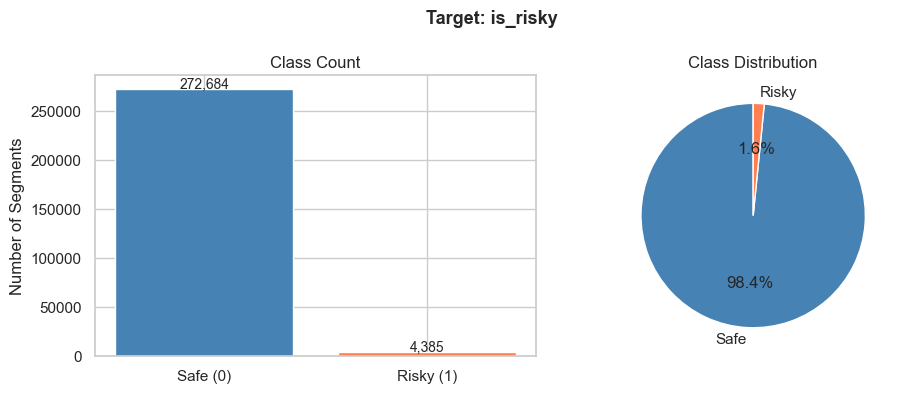

In [2]:
counts = df[TARGET].value_counts()
pcts   = df[TARGET].value_counts(normalize=True) * 100

print('=== Class Distribution ===')
for cls in counts.index:
    label = 'Risky (1)' if cls == 1 else 'Safe  (0)'
    print(f'  {label}: {counts[cls]:>7,}  ({pcts[cls]:.2f}%)')
print(f'\n  Imbalance Ratio (safe:risky): {counts[0]/counts[1]:.0f}:1')

if counts[0] / counts[1] > 10:
    print('  ⚠️  Severe imbalance. Use scale_pos_weight or SMOTE.')
elif counts[0] / counts[1] > 3:
    print('  ⚠️  Moderate imbalance. Use class_weight=balanced.')
else:
    print('  ✅ Acceptable imbalance.')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar
axes[0].bar(['Safe (0)', 'Risky (1)'], counts.values, color=['steelblue', 'coral'])
axes[0].set_title('Class Count')
axes[0].set_ylabel('Number of Segments')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

# Pie
axes[1].pie(counts.values, labels=['Safe', 'Risky'], autopct='%1.1f%%',
            colors=['steelblue', 'coral'], startangle=90)
axes[1].set_title('Class Distribution')

plt.suptitle('Target: is_risky', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. 🕳️ Missing Values & Data Quality

⚠️ Features with missing values:
speed_mean    4.912856


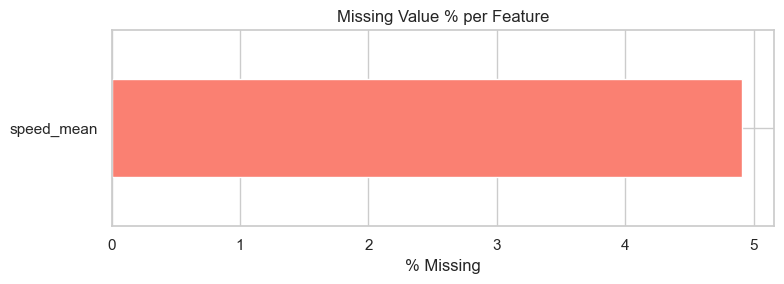


=== Constant / Zero-Variance Features ===
  ✅ No constant columns found.


In [3]:
null_pct = (df[FEATURES].isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

if len(null_pct) == 0:
    print('✅ No missing values in any feature!')
else:
    print('⚠️ Features with missing values:')
    print(null_pct.to_string())

    plt.figure(figsize=(8, max(3, len(null_pct) * 0.4)))
    null_pct.sort_values().plot(kind='barh', color='salmon')
    plt.title('Missing Value % per Feature')
    plt.xlabel('% Missing')
    plt.tight_layout()
    plt.show()

# Data types and constant columns
print('\n=== Constant / Zero-Variance Features ===')
const_cols = [c for c in FEATURES if df[c].nunique() <= 1]
if const_cols:
    print(f'  ❌ Drop these: {const_cols}')
else:
    print('  ✅ No constant columns found.')

---
## 3. 📊 Feature Distributions & Outliers

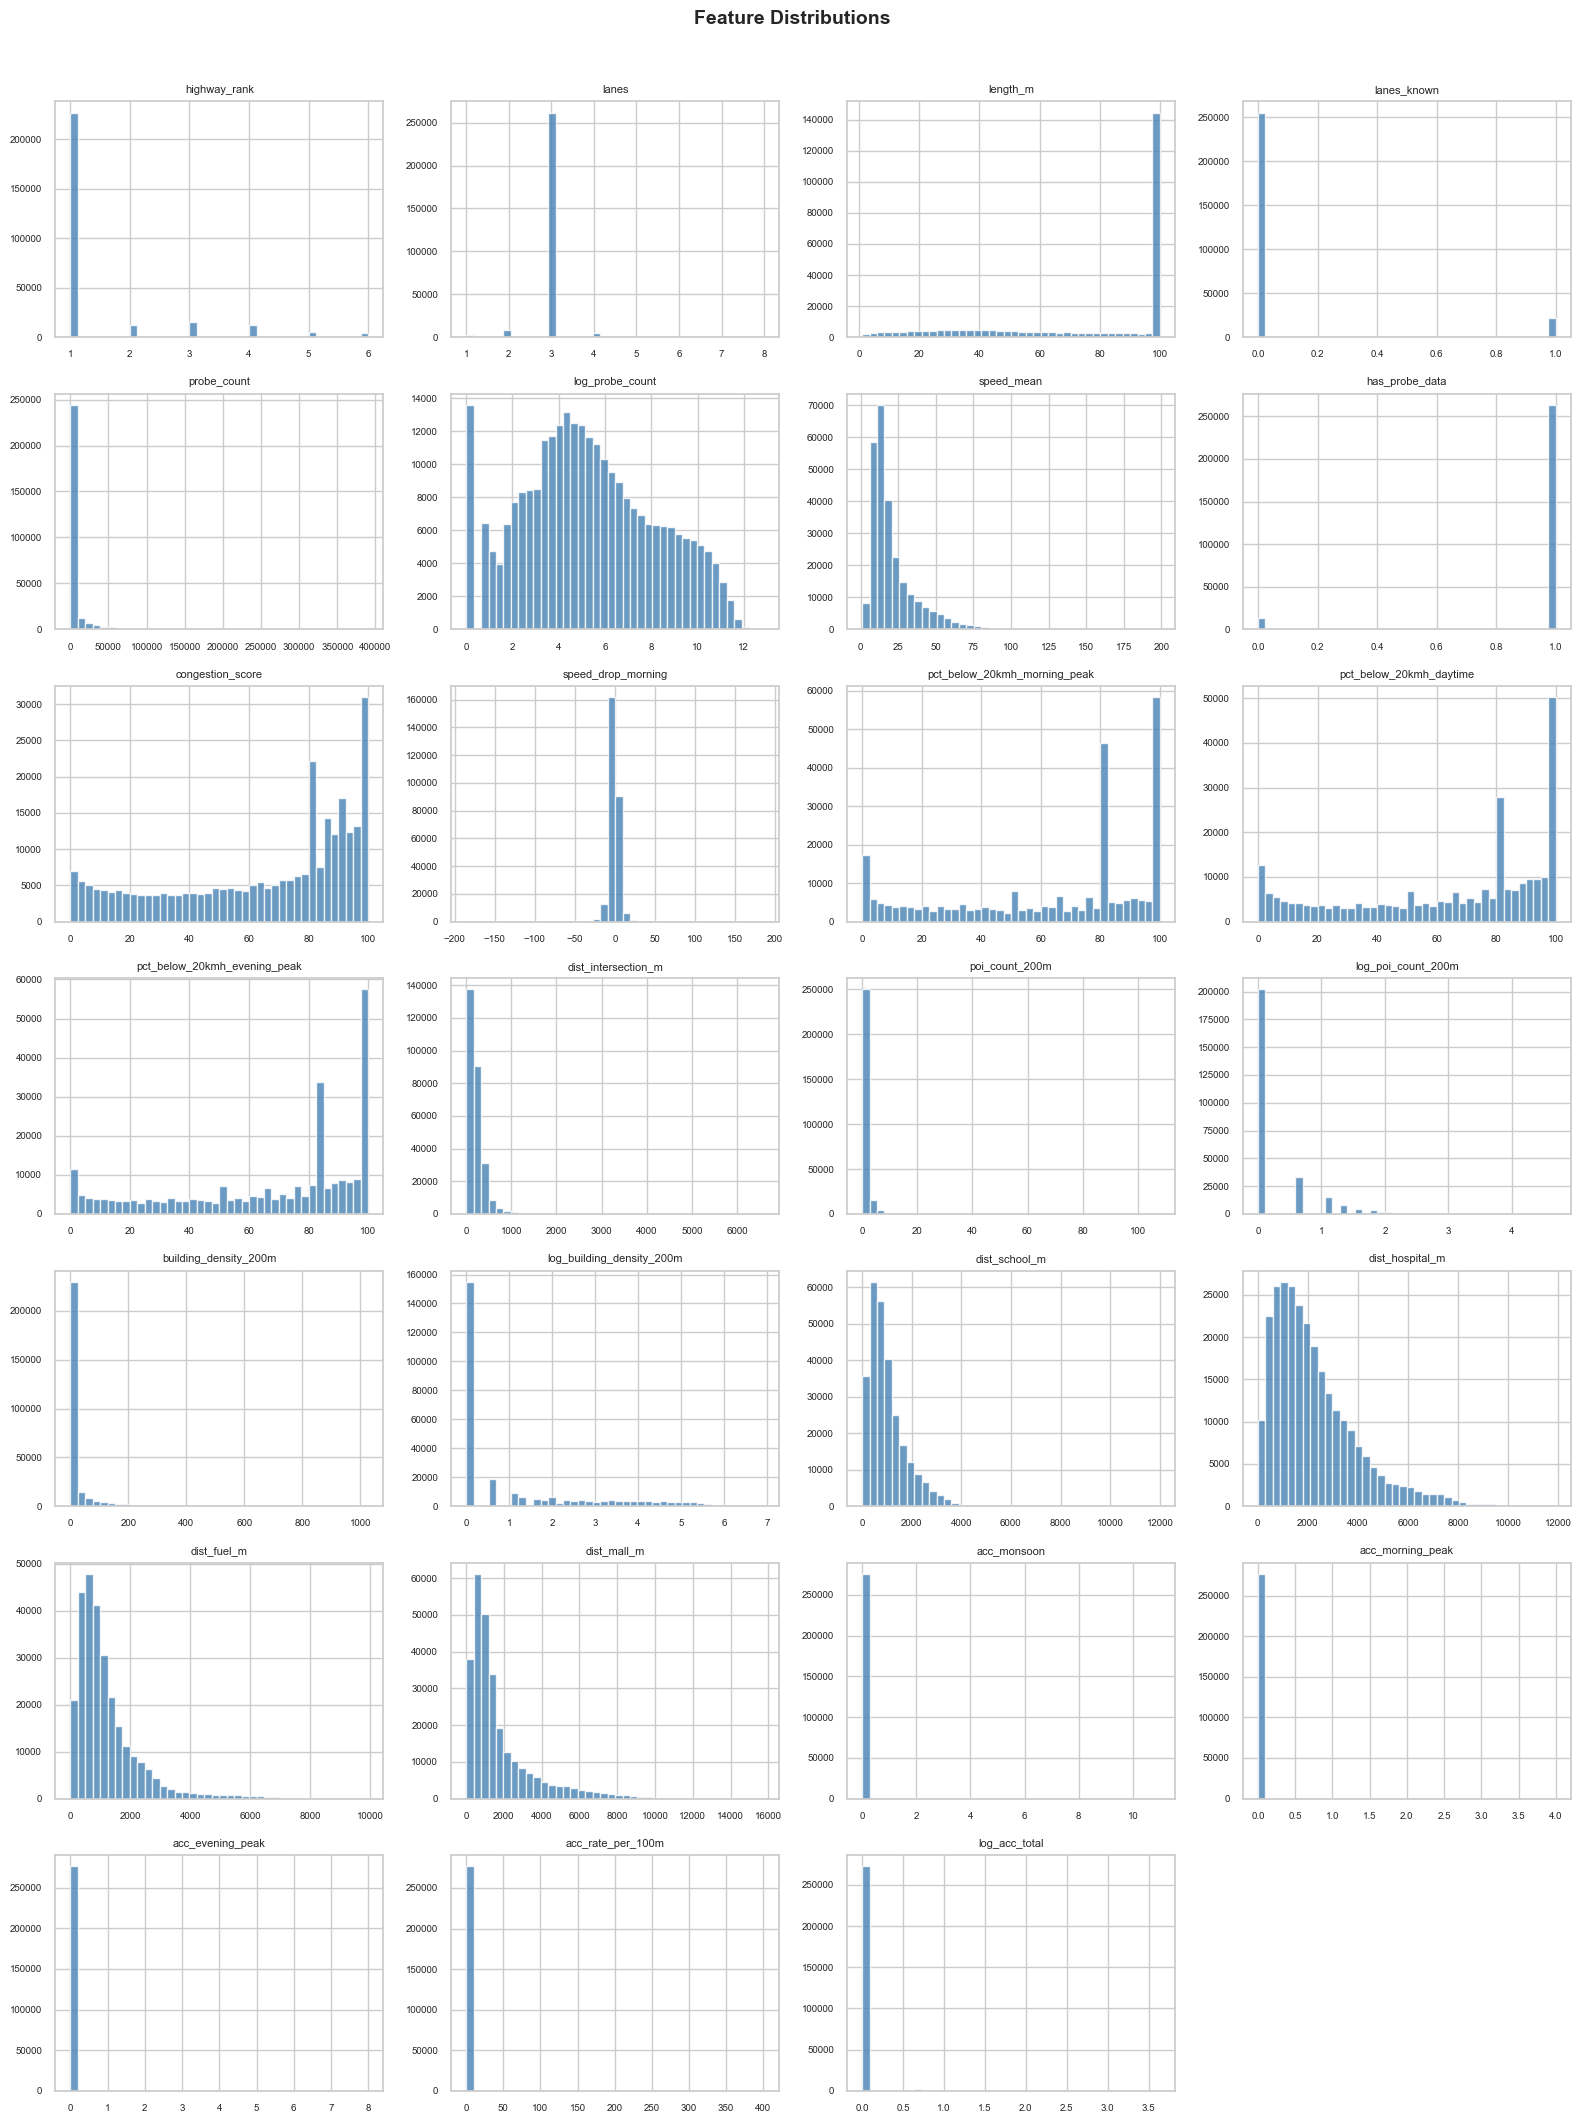

=== Highly Skewed Features (|skew| > 2) — Consider Log Transform ===
acc_rate_per_100m        100.25
acc_evening_peak          32.04
acc_morning_peak          30.46
acc_monsoon               28.41
log_acc_total             10.46
poi_count_200m             9.69
probe_count                5.19
building_density_200m      4.94
dist_intersection_m        4.88
dist_school_m              3.17
lanes_known                3.13
highway_rank               2.54
dist_fuel_m                2.53
log_poi_count_200m         2.33
dist_mall_m                2.05
speed_mean                 2.04
has_probe_data            -4.17


In [4]:
X = df[FEATURES].copy()
n_cols = 4
n_rows = (len(FEATURES) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    data = X[feat].dropna()
    axes[i].hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(feat, fontsize=8)
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=7)

# Hide unused subplots
for j in range(len(FEATURES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Skewness report
skews = X.skew().sort_values(ascending=False)
high_skew = skews[skews.abs() > 2]
print('=== Highly Skewed Features (|skew| > 2) — Consider Log Transform ===')
if len(high_skew) == 0:
    print('  ✅ No highly skewed features.')
else:
    print(high_skew.round(2).to_string())

---
## 4. 🔗 Correlation Matrix (Redundant Features)
Features with correlation > 0.9 are considered redundant — keeping both adds no information but increases complexity.

=== Pairs with |correlation| > 0.85 (Potentially Redundant) ===
  ⚠️  pct_below_20kmh_evening_peak        ↔ congestion_score                     r=0.948
  ⚠️  pct_below_20kmh_morning_peak        ↔ congestion_score                     r=0.947
  ⚠️  pct_below_20kmh_daytime             ↔ congestion_score                     r=0.937
  ⚠️  pct_below_20kmh_evening_peak        ↔ pct_below_20kmh_daytime              r=0.863


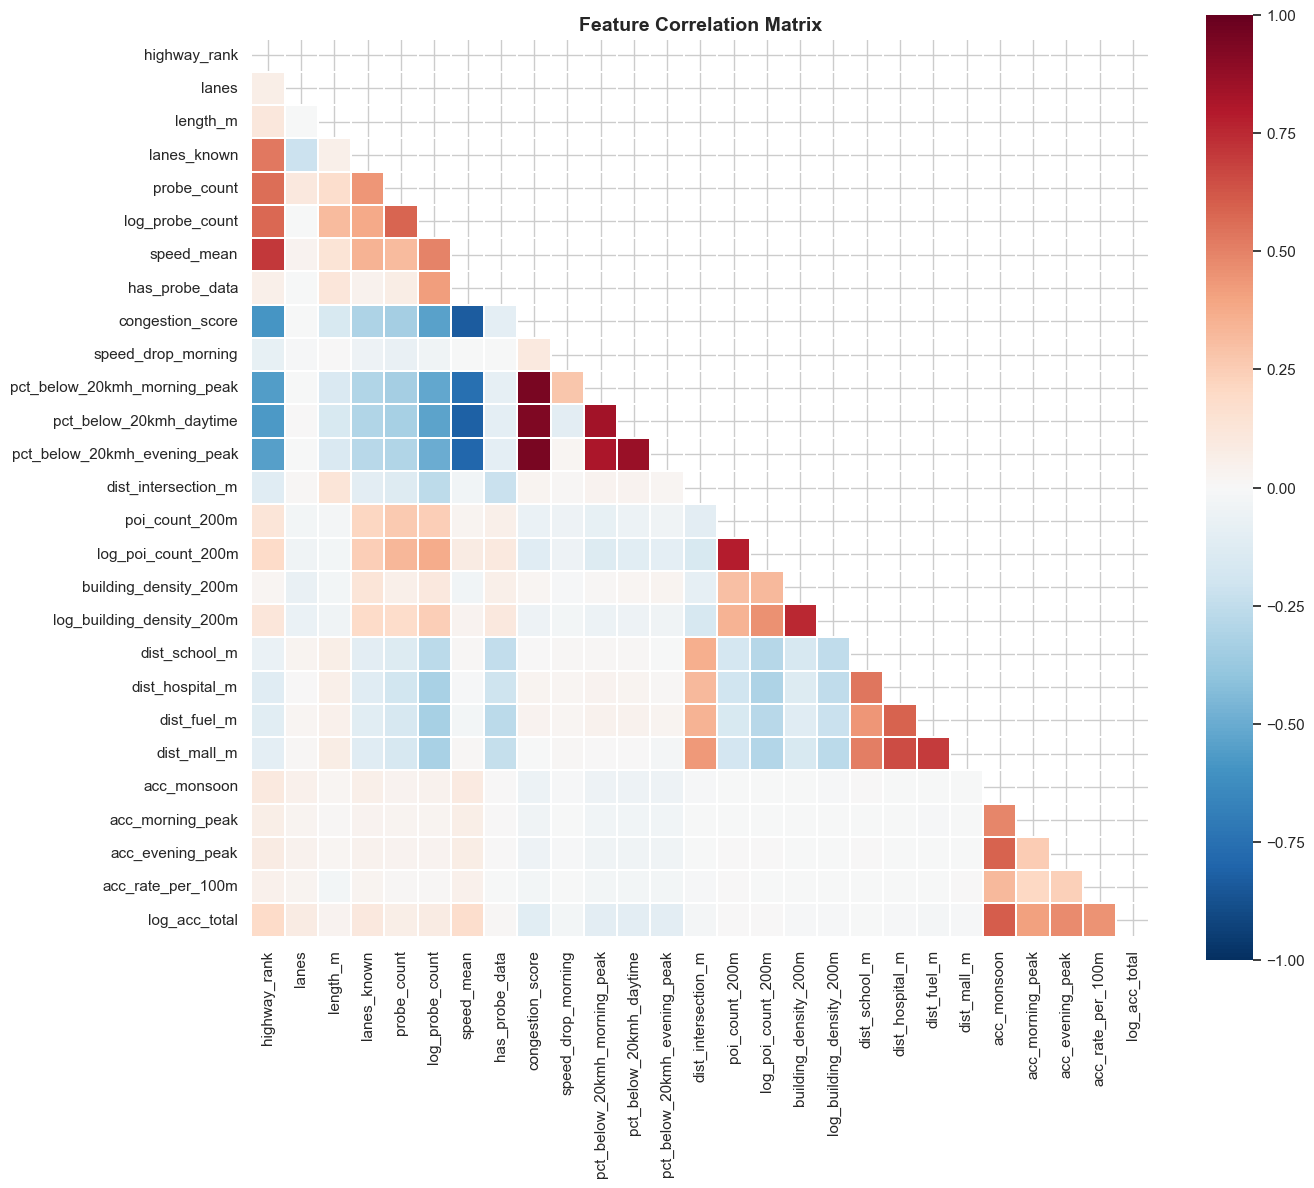

In [5]:
corr = X.corr()

# Find highly correlated pairs
threshold = 0.85
upper_tri = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_pairs = [(col, row, upper_tri.loc[row, col])
                   for col in upper_tri.columns
                   for row in upper_tri.index
                   if abs(upper_tri.loc[row, col]) > threshold
                   and not pd.isna(upper_tri.loc[row, col])]

print(f'=== Pairs with |correlation| > {threshold} (Potentially Redundant) ===')
if len(high_corr_pairs) == 0:
    print(f'  ✅ No highly correlated feature pairs found.')
else:
    for f1, f2, r in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f'  ⚠️  {f1:35s} ↔ {f2:35s}  r={r:.3f}')

# Heatmap
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=len(FEATURES) <= 15, fmt='.1f', linewidths=0.3,
            ax=ax, square=True)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. 📈 Feature vs Target Relationship
Compare feature distributions between Safe (0) and Risky (1) segments to see which features actually separate the classes.

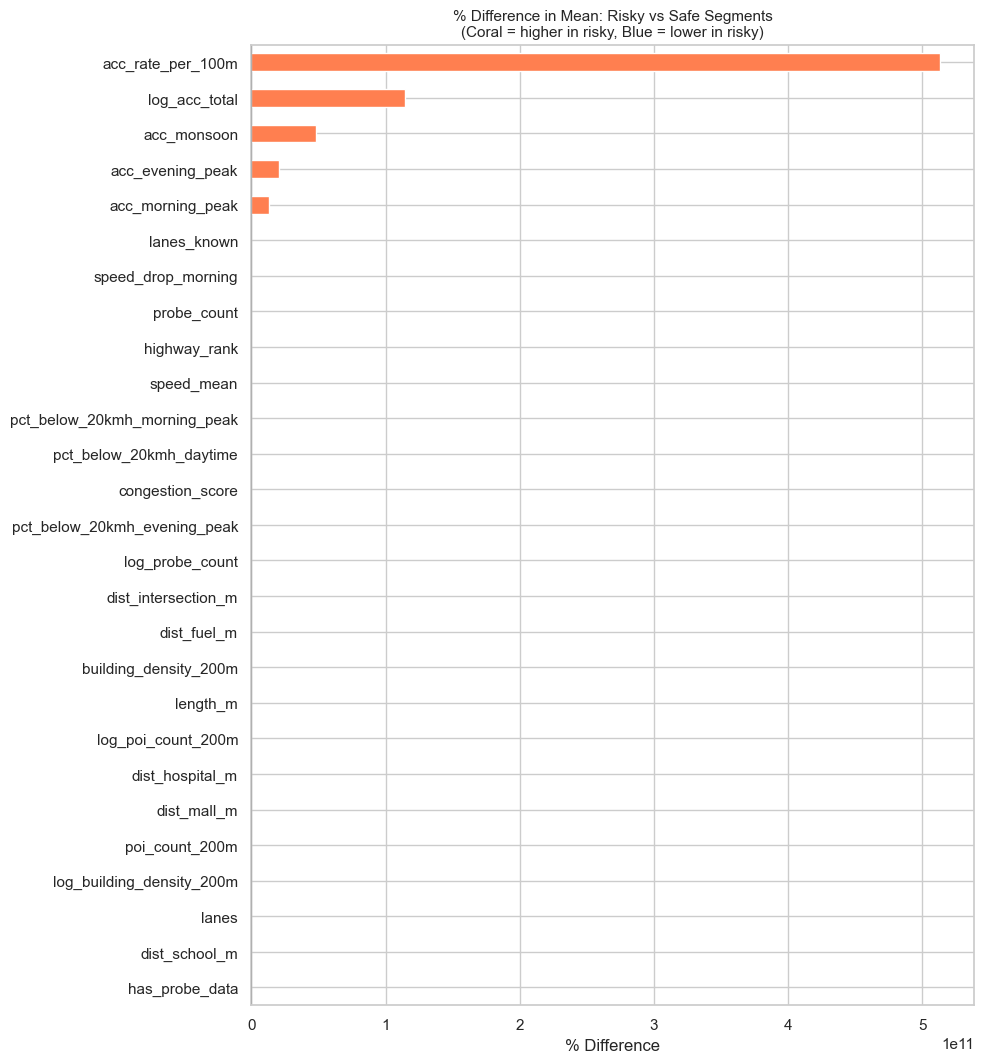

=== Top 5 features where Risky segments differ most from Safe ===
acc_rate_per_100m    5.129046e+11
log_acc_total        1.148682e+11
acc_monsoon          4.832383e+10
acc_evening_peak     2.034208e+10
acc_morning_peak     1.315849e+10


In [6]:
X_with_target = df[FEATURES + [TARGET]].copy()

# Compute mean per class for each feature
group_means = X_with_target.groupby(TARGET)[FEATURES].mean()
diff = ((group_means.loc[1] - group_means.loc[0]) / (group_means.loc[0].abs() + 1e-9) * 100)
diff = diff.sort_values(key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(FEATURES) * 0.4)))
colors = ['coral' if v > 0 else 'steelblue' for v in diff]
diff.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('% Difference in Mean: Risky vs Safe Segments\n(Coral = higher in risky, Blue = lower in risky)', fontsize=11)
ax.set_xlabel('% Difference')
plt.tight_layout()
plt.show()

print('=== Top 5 features where Risky segments differ most from Safe ===')
print(diff.abs().sort_values(ascending=False).head(5).round(1).to_string())

---
## 6. ✅ Summary & Modeling Recommendations

In [7]:
ratio = counts[0] / counts[1]
print('=' * 55)
print('  PRE-MODELING EDA SUMMARY')
print('=' * 55)
print(f'  Total Segments : {len(df):,}')
print(f'  Features Used  : {len(FEATURES)}')
print(f'  Target         : {TARGET}')
print()
print(f'  ● Class Ratio (safe:risky): {ratio:.0f}:1')
print(f'    → Use scale_pos_weight={ratio:.0f} in XGBoost')
print()
if len(null_pct) > 0:
    print(f'  ● Missing Values: {len(null_pct)} feature(s) have NaN')
    print(f'    → preprocess.py should have handled these')
else:
    print(f'  ● Missing Values: None ✅')
print()
if len(high_corr_pairs) > 0:
    to_drop = list(set([p[1] for p in high_corr_pairs]))
    print(f'  ● Redundant Features: {len(high_corr_pairs)} pair(s) above {threshold}')
    print(f'    → Consider removing: {to_drop}')
else:
    print(f'  ● Redundant Features: None above threshold ✅')
print()
if len(high_skew) > 0:
    print(f'  ● Skewed Features: {len(high_skew)} feature(s) — use log_ variants')
else:
    print(f'  ● Skewed Features: None ✅')
print('=' * 55)

  PRE-MODELING EDA SUMMARY
  Total Segments : 277,069
  Features Used  : 27
  Target         : is_risky

  ● Class Ratio (safe:risky): 62:1
    → Use scale_pos_weight=62 in XGBoost

  ● Missing Values: 1 feature(s) have NaN
    → preprocess.py should have handled these

  ● Redundant Features: 4 pair(s) above 0.85
    → Consider removing: ['congestion_score', 'pct_below_20kmh_daytime']

  ● Skewed Features: 17 feature(s) — use log_ variants
